In [1]:
import pandas as pd
import numpy as np
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
DATA_PATH = Path(
    r"C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\data\processed\emi_prediction_dataset_cleaned.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (404800, 27)


In [3]:
TARGET = "emi_eligibility"

exclude_columns = [
    "emi_eligibility",
    "max_monthly_emi"
]

X = df.drop(columns=exclude_columns).copy()
y = df[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
display(y.value_counts())

X shape: (404800, 25)
y shape: (404800,)

Target distribution:


emi_eligibility
Not_Eligible    312868
Eligible         74444
High_Risk        17488
Name: count, dtype: int64

In [4]:
expense_columns = [
    "monthly_rent",
    "school_fees",
    "college_fees",
    "travel_expenses",
    "groceries_utilities",
    "other_monthly_expenses"
]

# Total living expenses
df["total_living_expenses"] = df[expense_columns].sum(axis=1)

# Total monthly commitments
df["total_monthly_commitments"] = (
    df["total_living_expenses"]
    + df["current_emi_amount"]
)

# Disposable income
df["disposable_income"] = (
    df["monthly_salary"]
    - df["total_monthly_commitments"]
)

# Prevent division by zero
salary_safe = df["monthly_salary"].replace(0, np.nan)

# Financial ratios
df["expense_to_income_ratio"] = (
    df["total_living_expenses"] / salary_safe
)

df["commitment_to_income_ratio"] = (
    df["total_monthly_commitments"] / salary_safe
)

df["current_emi_to_income_ratio"] = (
    df["current_emi_amount"] / salary_safe
)

df["requested_amount_to_income"] = (
    df["requested_amount"] / salary_safe
)

df["emergency_fund_to_income"] = (
    df["emergency_fund"] / salary_safe
)

print("Financial features recreated successfully!")

Financial features recreated successfully!


In [5]:
exclude_columns = [
    "emi_eligibility",
    "max_monthly_emi"
]

X = df.drop(columns=exclude_columns).copy()
y = df["emi_eligibility"].copy()

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

print("\nFeature count:", X.shape[1])

Final X shape: (404800, 33)
Final y shape: (404800,)

Feature count: 33


In [6]:
print("emi_eligibility in X:", "emi_eligibility" in X.columns)
print("max_monthly_emi in X:", "max_monthly_emi" in X.columns)

emi_eligibility in X: False
max_monthly_emi in X: False


In [7]:
print("Missing values in X:", X.isnull().sum().sum())
print("Infinite values in X:", np.isinf(X.select_dtypes(include=np.number)).sum().sum())

print("\nFinal X shape:", X.shape)
print("Final y shape:", y.shape)

Missing values in X: 0
Infinite values in X: 0

Final X shape: (404800, 33)
Final y shape: (404800,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training X:", X_train.shape)
print("Testing X :", X_test.shape)

print("Training y:", y_train.shape)
print("Testing y :", y_test.shape)

Training X: (323840, 33)
Testing X : (80960, 33)
Training y: (323840,)
Testing y : (80960,)


In [9]:
print("Original Dataset:")
display(
    y.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTraining Dataset:")
display(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting Dataset:")
display(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Original Dataset:


emi_eligibility
Not_Eligible    77.29
Eligible        18.39
High_Risk        4.32
Name: proportion, dtype: float64


Training Dataset:


emi_eligibility
Not_Eligible    77.29
Eligible        18.39
High_Risk        4.32
Name: proportion, dtype: float64


Testing Dataset:


emi_eligibility
Not_Eligible    77.29
Eligible        18.39
High_Risk        4.32
Name: proportion, dtype: float64

In [10]:
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numerical features: 25
['age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount', 'requested_tenure', 'total_living_expenses', 'total_monthly_commitments', 'disposable_income', 'expense_to_income_ratio', 'commitment_to_income_ratio', 'current_emi_to_income_ratio', 'requested_amount_to_income', 'emergency_fund_to_income']

Categorical features: 8
['gender', 'marital_status', 'education', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'emi_scenario']


In [11]:

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [12]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (323840, 33)
Processed training shape: (323840, 51)

Original testing shape: (80960, 33)
Processed testing shape: (80960, 51)


In [13]:
print("Processed training data type:")
print(type(X_train_processed))

print("\nProcessed testing data type:")
print(type(X_test_processed))

print("\nNaN values in training:",
      np.isnan(X_train_processed).sum())

print("NaN values in testing:",
      np.isnan(X_test_processed).sum())

print("\nInfinite values in training:",
      np.isinf(X_train_processed).sum())

print("Infinite values in testing:",
      np.isinf(X_test_processed).sum())

Processed training data type:
<class 'numpy.ndarray'>

Processed testing data type:
<class 'numpy.ndarray'>

NaN values in training: 0
NaN values in testing: 0

Infinite values in training: 0
Infinite values in testing: 0


In [14]:
import joblib
from pathlib import Path

ARTIFACTS_PATH = Path(
    r"C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\artifacts"
)

ARTIFACTS_PATH.mkdir(
    parents=True,
    exist_ok=True
)

preprocessor_path = (
    ARTIFACTS_PATH /
    "classification_preprocessor.pkl"
)

joblib.dump(
    preprocessor,
    preprocessor_path
)

print("Classification preprocessor saved successfully!")
print("Path:", preprocessor_path)

Classification preprocessor saved successfully!
Path: C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\artifacts\classification_preprocessor.pkl


In [15]:
import pandas as pd
import numpy as np
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [16]:
DATA_PATH = Path(
    r"C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\data\processed\emi_prediction_dataset_cleaned.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (404800, 27)


In [17]:
expense_columns = [
    "monthly_rent",
    "school_fees",
    "college_fees",
    "travel_expenses",
    "groceries_utilities",
    "other_monthly_expenses"
]

df["total_living_expenses"] = df[expense_columns].sum(axis=1)

df["total_monthly_commitments"] = (
    df["total_living_expenses"]
    + df["current_emi_amount"]
)

df["disposable_income"] = (
    df["monthly_salary"]
    - df["total_monthly_commitments"]
)

salary_safe = df["monthly_salary"].replace(0, np.nan)

df["expense_to_income_ratio"] = (
    df["total_living_expenses"] / salary_safe
)

df["commitment_to_income_ratio"] = (
    df["total_monthly_commitments"] / salary_safe
)

df["current_emi_to_income_ratio"] = (
    df["current_emi_amount"] / salary_safe
)

df["requested_amount_to_income"] = (
    df["requested_amount"] / salary_safe
)

df["emergency_fund_to_income"] = (
    df["emergency_fund"] / salary_safe
)

print("Financial features recreated successfully!")

Financial features recreated successfully!


In [18]:
TARGET = "emi_eligibility"

X = df.drop(
    columns=["emi_eligibility", "max_monthly_emi"]
).copy()

y = df[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
display(y.value_counts())

X shape: (404800, 33)
y shape: (404800,)

Target distribution:


emi_eligibility
Not_Eligible    312868
Eligible         74444
High_Risk        17488
Name: count, dtype: int64

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (323840, 33)
Testing : (80960, 33)


In [21]:
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training:", X_train_processed.shape)
print("Processed testing :", X_test_processed.shape)

Processed training: (323840, 51)
Processed testing : (80960, 51)


In [22]:
from sklearn.linear_model import LogisticRegression

In [33]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [24]:
y_pred_logistic = logistic_model.predict(
    X_test_processed
)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_logistic))

Predictions generated successfully!
Number of predictions: 80960


In [25]:
accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred_logistic
)

precision = precision_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

print("=" * 60)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 60)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Balanced Accuracy  : {balanced_accuracy:.4f}")
print(f"Weighted Precision : {precision:.4f}")
print(f"Weighted Recall    : {recall:.4f}")
print(f"Weighted F1-Score  : {f1:.4f}")

LOGISTIC REGRESSION RESULTS
Accuracy           : 0.7957
Balanced Accuracy  : 0.7513
Weighted Precision : 0.9226
Weighted Recall    : 0.7957
Weighted F1-Score  : 0.8448


In [26]:
print("LOGISTIC REGRESSION CLASSIFICATION REPORT")


print(
    classification_report(
        y_test,
        y_pred_logistic,
        digits=4
    )
)

LOGISTIC REGRESSION CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Eligible     0.8387    0.7601    0.7975     14889
   High_Risk     0.1491    0.6834    0.2448      3497
Not_Eligible     0.9858    0.8104    0.8895     62574

    accuracy                         0.7957     80960
   macro avg     0.6579    0.7513    0.6439     80960
weighted avg     0.9226    0.7957    0.8448     80960



In [27]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

print("Confusion Matrix:")
print(cm_logistic)

Confusion Matrix:
[[11317  3193   379]
 [  758  2390   349]
 [ 1418 10447 50709]]


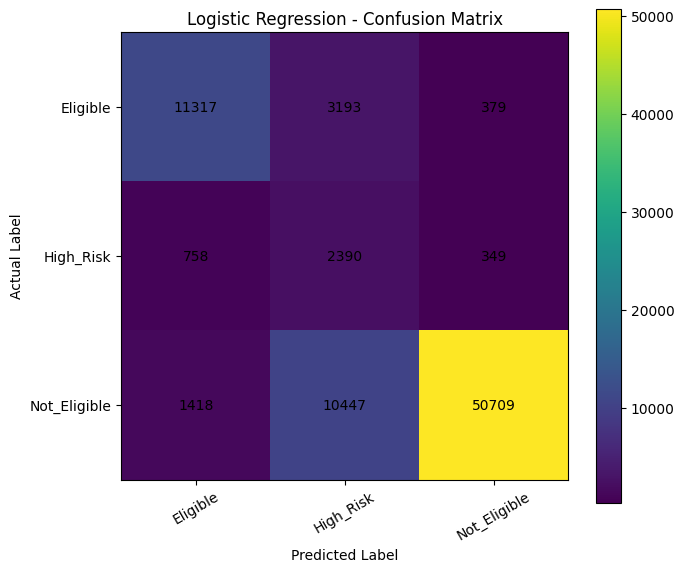

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.imshow(cm_logistic)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    range(len(logistic_model.classes_)),
    logistic_model.classes_,
    rotation=30
)

plt.yticks(
    range(len(logistic_model.classes_)),
    logistic_model.classes_
)

plt.colorbar()

for i in range(cm_logistic.shape[0]):
    for j in range(cm_logistic.shape[1]):
        plt.text(
            j,
            i,
            cm_logistic[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [29]:
from pathlib import Path
import joblib

MODEL_PATH = Path(
    r"C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\models\classification"
)

MODEL_PATH.mkdir(
    parents=True,
    exist_ok=True
)

logistic_path = MODEL_PATH / "logistic_regression.pkl"

joblib.dump(
    logistic_model,
    logistic_path
)

print("Logistic Regression model saved!")
print("Path:", logistic_path)

Logistic Regression model saved!
Path: C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\models\classification\logistic_regression.pkl


In [30]:
from sklearn.ensemble import RandomForestClassifier

In [31]:
random_forest_model = RandomForestClassifier(
    n_estimators=150,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

random_forest_model.fit(
    X_train_processed,
    y_train
)

Training Random Forest...


,n_estimators,150
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
y_pred_rf = random_forest_model.predict(
    X_test_processed
)

print("Random Forest predictions generated!")
print("Number of predictions:", len(y_pred_rf))

Random Forest predictions generated!
Number of predictions: 80960


In [34]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rf_macro_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="macro"
)

print("=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)

print(f"Accuracy           : {rf_accuracy:.4f}")
print(f"Balanced Accuracy  : {rf_balanced_accuracy:.4f}")
print(f"Weighted Precision : {rf_precision:.4f}")
print(f"Weighted Recall    : {rf_recall:.4f}")
print(f"Weighted F1-Score  : {rf_f1:.4f}")
print(f"Macro F1-Score     : {rf_macro_f1:.4f}")

RANDOM FOREST RESULTS
Accuracy           : 0.9423
Balanced Accuracy  : 0.6516
Weighted Precision : 0.9338
Weighted Recall    : 0.9423
Weighted F1-Score  : 0.9230
Macro F1-Score     : 0.6466


In [35]:
print("=" * 60)
print("RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_rf,
        digits=4
    )
)

RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Eligible     0.9091    0.9365    0.9226     14889
   High_Risk     0.7431    0.0232    0.0449      3497
Not_Eligible     0.9504    0.9950    0.9722     62574

    accuracy                         0.9423     80960
   macro avg     0.8675    0.6516    0.6466     80960
weighted avg     0.9338    0.9423    0.9230     80960



In [36]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[13944    20   925]
 [ 1091    81  2325]
 [  304     8 62262]]


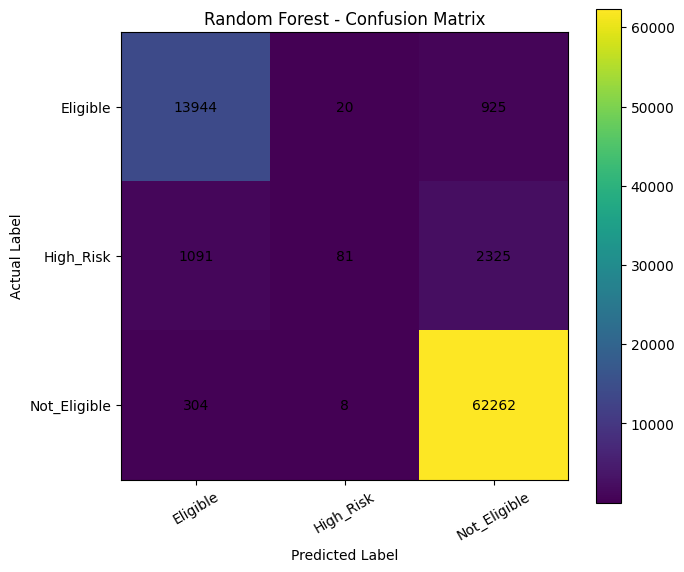

In [37]:
plt.figure(figsize=(7, 6))

plt.imshow(cm_rf)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    range(len(random_forest_model.classes_)),
    random_forest_model.classes_,
    rotation=30
)

plt.yticks(
    range(len(random_forest_model.classes_)),
    random_forest_model.classes_
)

plt.colorbar()

for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        plt.text(
            j,
            i,
            cm_rf[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [38]:
MODEL_PATH = Path(
    r"C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\models\classification"
)

MODEL_PATH.mkdir(
    parents=True,
    exist_ok=True
)

rf_path = MODEL_PATH / "random_forest.pkl"

joblib.dump(
    random_forest_model,
    rf_path
)

print("Random Forest model saved successfully!")
print("Path:", rf_path)

Random Forest model saved successfully!
Path: C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\models\classification\random_forest.pkl


In [39]:
from sklearn.ensemble import GradientBoostingClassifier

In [40]:
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

print("Training Gradient Boosting...")

gradient_boosting_model.fit(
    X_train_processed,
    y_train
)

Training Gradient Boosting...


,loss,'log_loss'
,learning_rate,0.05
,n_estimators,150
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [41]:
y_pred_gb = gradient_boosting_model.predict(
    X_test_processed
)

print("Gradient Boosting predictions generated!")
print("Number of predictions:", len(y_pred_gb))

Gradient Boosting predictions generated!
Number of predictions: 80960


In [42]:

gb_accuracy = accuracy_score(
    y_test,
    y_pred_gb
)

gb_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred_gb
)

gb_precision = precision_score(
    y_test,
    y_pred_gb,
    average="weighted"
)

gb_recall = recall_score(
    y_test,
    y_pred_gb,
    average="weighted"
)

gb_f1 = f1_score(
    y_test,
    y_pred_gb,
    average="weighted"
)

gb_macro_f1 = f1_score(
    y_test,
    y_pred_gb,
    average="macro"
)

print("=" * 60)
print("GRADIENT BOOSTING RESULTS")
print("=" * 60)

print(f"Accuracy           : {gb_accuracy:.4f}")
print(f"Balanced Accuracy  : {gb_balanced_accuracy:.4f}")
print(f"Weighted Precision : {gb_precision:.4f}")
print(f"Weighted Recall    : {gb_recall:.4f}")
print(f"Weighted F1-Score  : {gb_f1:.4f}")
print(f"Macro F1-Score     : {gb_macro_f1:.4f}")

GRADIENT BOOSTING RESULTS
Accuracy           : 0.9400
Balanced Accuracy  : 0.6413
Weighted Precision : 0.8992
Weighted Recall    : 0.9400
Weighted F1-Score  : 0.9191
Macro F1-Score     : 0.6295


In [43]:
print("=" * 60)
print("GRADIENT BOOSTING CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_gb,
        digits=4
    )
)

GRADIENT BOOSTING CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Eligible     0.9072    0.9286    0.9178     14889
   High_Risk     0.0000    0.0000    0.0000      3497
Not_Eligible     0.9476    0.9952    0.9708     62574

    accuracy                         0.9400     80960
   macro avg     0.6183    0.6413    0.6295     80960
weighted avg     0.8992    0.9400    0.9191     80960



In [44]:
cm_gb = confusion_matrix(
    y_test,
    y_pred_gb
)

print("Gradient Boosting Confusion Matrix:")
print(cm_gb)

Gradient Boosting Confusion Matrix:
[[13826     1  1062]
 [ 1116     0  2381]
 [  299     0 62275]]


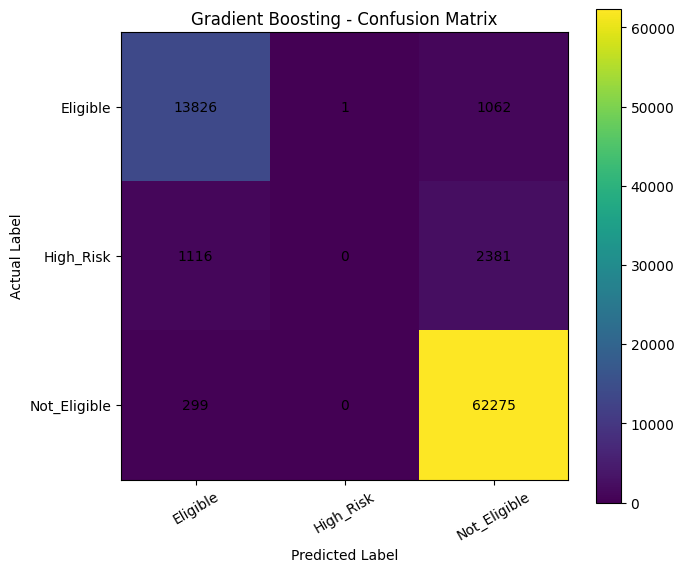

In [45]:
plt.figure(figsize=(7, 6))

plt.imshow(cm_gb)

plt.title("Gradient Boosting - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    range(len(gradient_boosting_model.classes_)),
    gradient_boosting_model.classes_,
    rotation=30
)

plt.yticks(
    range(len(gradient_boosting_model.classes_)),
    gradient_boosting_model.classes_
)

plt.colorbar()

for i in range(cm_gb.shape[0]):
    for j in range(cm_gb.shape[1]):
        plt.text(
            j,
            i,
            cm_gb[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [46]:
gb_path = MODEL_PATH / "gradient_boosting.pkl"

joblib.dump(
    gradient_boosting_model,
    gb_path
)

print("Gradient Boosting model saved successfully!")
print("Path:", gb_path)

Gradient Boosting model saved successfully!
Path: C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\models\classification\gradient_boosting.pkl


In [47]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        gb_accuracy
    ],
    "Balanced Accuracy": [
        balanced_accuracy,
        rf_balanced_accuracy,
        gb_balanced_accuracy
    ],
    "Weighted Precision": [
        precision,
        rf_precision,
        gb_precision
    ],
    "Weighted Recall": [
        recall,
        rf_recall,
        gb_recall
    ],
    "Weighted F1": [
        f1,
        rf_f1,
        gb_f1
    ],
    "Macro F1": [
        f1_score(y_test, y_pred_logistic, average="macro"),
        rf_macro_f1,
        gb_macro_f1
    ]
})

results = results.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

display(
    results.style.format({
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "Weighted Precision": "{:.4f}",
        "Weighted Recall": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)

,Model,Accuracy,Balanced Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro F1
0,Random Forest,0.9423,0.6516,0.9338,0.9423,0.9230,0.6466
1,Logistic Regression,0.7957,0.7513,0.9226,0.7957,0.8448,0.6439
2,Gradient Boosting,0.9400,0.6413,0.8992,0.9400,0.9191,0.6295


In [48]:
high_risk_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "High_Risk Precision": [
        precision_score(
            y_test,
            y_pred_logistic,
            labels=["High_Risk"],
            average="macro",
            zero_division=0
        ),
        precision_score(
            y_test,
            y_pred_rf,
            labels=["High_Risk"],
            average="macro",
            zero_division=0
        ),
        precision_score(
            y_test,
            y_pred_gb,
            labels=["High_Risk"],
            average="macro",
            zero_division=0
        )
    ],
    "High_Risk Recall": [
        recall_score(
            y_test,
            y_pred_logistic,
            labels=["High_Risk"],
            average="macro",
            zero_division=0
        ),
        recall_score(
            y_test,
            y_pred_rf,
            labels=["High_Risk"],
            average="macro",
            zero_division=0
        ),
        recall_score(
            y_test,
            y_pred_gb,
            labels=["High_Risk"],
            average="macro",
            zero_division=0
        )
    ],
    "High_Risk F1": [
        f1_score(
            y_test,
            y_pred_logistic,
            labels=["High_Risk"],
            average="macro",
            zero_division=0
        ),
        f1_score(
            y_test,
            y_pred_rf,
            labels=["High_Risk"],
            average="macro",
            zero_division=0
        ),
        f1_score(
            y_test,
            y_pred_gb,
            labels=["High_Risk"],
            average="macro",
            zero_division=0
        )
    ]
})

display(
    high_risk_results.style.format({
        "High_Risk Precision": "{:.4f}",
        "High_Risk Recall": "{:.4f}",
        "High_Risk F1": "{:.4f}"
    })
)

,Model,High_Risk Precision,High_Risk Recall,High_Risk F1
0,Logistic Regression,0.1491,0.6834,0.2448
1,Random Forest,0.7431,0.0232,0.0449
2,Gradient Boosting,0.0000,0.0000,0.0000


In [49]:
tuned_rf = RandomForestClassifier(
    n_estimators=150,
    class_weight={
        "Not_Eligible": 1.0,
        "Eligible": 1.5,
        "High_Risk": 8.0
    },
    random_state=42,
    n_jobs=-1
)

print("Training tuned Random Forest...")

tuned_rf.fit(
    X_train_processed,
    y_train
)

print("Tuned Random Forest trained successfully!")

Training tuned Random Forest...
Tuned Random Forest trained successfully!


In [50]:
y_pred_tuned_rf = tuned_rf.predict(
    X_test_processed
)

print("Predictions generated successfully!")

Predictions generated successfully!


In [51]:
tuned_rf_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_rf
)

tuned_rf_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred_tuned_rf
)

tuned_rf_precision = precision_score(
    y_test,
    y_pred_tuned_rf,
    average="weighted",
    zero_division=0
)

tuned_rf_recall = recall_score(
    y_test,
    y_pred_tuned_rf,
    average="weighted",
    zero_division=0
)

tuned_rf_f1 = f1_score(
    y_test,
    y_pred_tuned_rf,
    average="weighted",
    zero_division=0
)

tuned_rf_macro_f1 = f1_score(
    y_test,
    y_pred_tuned_rf,
    average="macro",
    zero_division=0
)

print("=" * 60)
print("TUNED RANDOM FOREST RESULTS")
print("=" * 60)

print(f"Accuracy           : {tuned_rf_accuracy:.4f}")
print(f"Balanced Accuracy  : {tuned_rf_balanced_accuracy:.4f}")
print(f"Weighted Precision : {tuned_rf_precision:.4f}")
print(f"Weighted Recall    : {tuned_rf_recall:.4f}")
print(f"Weighted F1        : {tuned_rf_f1:.4f}")
print(f"Macro F1           : {tuned_rf_macro_f1:.4f}")

TUNED RANDOM FOREST RESULTS
Accuracy           : 0.9432
Balanced Accuracy  : 0.6553
Weighted Precision : 0.9343
Weighted Recall    : 0.9432
Weighted F1        : 0.9243
Macro F1           : 0.6493


In [52]:
print("=" * 60)
print("TUNED RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_tuned_rf,
        digits=4,
        zero_division=0
    )
)

TUNED RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Eligible     0.8991    0.9445    0.9213     14889
   High_Risk     0.7273    0.0275    0.0529      3497
Not_Eligible     0.9542    0.9941    0.9737     62574

    accuracy                         0.9432     80960
   macro avg     0.8602    0.6553    0.6493     80960
weighted avg     0.9343    0.9432    0.9243     80960



In [53]:
cm_tuned_rf = confusion_matrix(
    y_test,
    y_pred_tuned_rf
)

print("Tuned Random Forest Confusion Matrix:")
print(cm_tuned_rf)

Tuned Random Forest Confusion Matrix:
[[14063    25   801]
 [ 1218    96  2183]
 [  360    11 62203]]


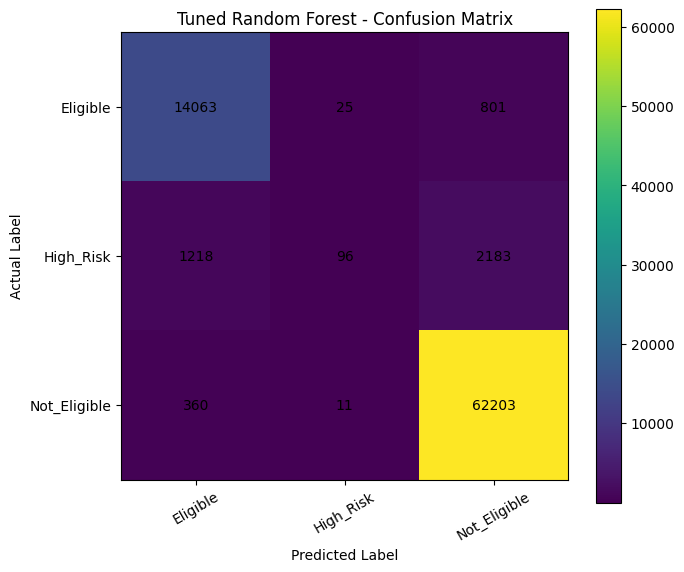

In [54]:
plt.figure(figsize=(7, 6))

plt.imshow(cm_tuned_rf)

plt.title("Tuned Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    range(len(tuned_rf.classes_)),
    tuned_rf.classes_,
    rotation=30
)

plt.yticks(
    range(len(tuned_rf.classes_)),
    tuned_rf.classes_
)

plt.colorbar()

for i in range(cm_tuned_rf.shape[0]):
    for j in range(cm_tuned_rf.shape[1]):
        plt.text(
            j,
            i,
            cm_tuned_rf[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [55]:
final_model = logistic_model
final_model_name = "Logistic Regression"

print("=" * 60)
print("FINAL CLASSIFICATION MODEL")
print("=" * 60)

print("Selected Model:", final_model_name)
print("Reason: Best Balanced Accuracy and High_Risk Recall")

print("\nPerformance:")
print(f"Accuracy          : {accuracy:.4f}")
print(f"Balanced Accuracy : {balanced_accuracy:.4f}")
print(f"Macro F1          : {f1_score(y_test, y_pred_logistic, average='macro'):.4f}")
print(f"High_Risk Recall  : 0.6834")
print(f"High_Risk F1      : 0.2448")

FINAL CLASSIFICATION MODEL
Selected Model: Logistic Regression
Reason: Best Balanced Accuracy and High_Risk Recall

Performance:
Accuracy          : 0.7957
Balanced Accuracy : 0.7513
Macro F1          : 0.6439
High_Risk Recall  : 0.6834
High_Risk F1      : 0.2448


In [56]:
FINAL_MODEL_PATH = Path(
    r"C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\models\final"
)

FINAL_MODEL_PATH.mkdir(
    parents=True,
    exist_ok=True
)

final_classifier_path = (
    FINAL_MODEL_PATH / "emi_eligibility_classifier.pkl"
)

joblib.dump(
    final_model,
    final_classifier_path
)

print("Final classifier saved successfully!")
print("Path:", final_classifier_path)

Final classifier saved successfully!
Path: C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\models\final\emi_eligibility_classifier.pkl


In [57]:
FINAL_MODEL_PATH = Path(
    r"C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\models\final"
)

FINAL_MODEL_PATH.mkdir(
    parents=True,
    exist_ok=True
)

final_classifier_path = (
    FINAL_MODEL_PATH / "emi_eligibility_classifier.pkl"
)

joblib.dump(
    final_model,
    final_classifier_path
)

print("Final classifier saved successfully!")
print("Path:", final_classifier_path)

Final classifier saved successfully!
Path: C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\models\final\emi_eligibility_classifier.pkl


In [58]:
final_preprocessor_path = (
    FINAL_MODEL_PATH / "classification_preprocessor.pkl"
)

joblib.dump(
    preprocessor,
    final_preprocessor_path
)

print("Final preprocessor saved successfully!")
print("Path:", final_preprocessor_path)

Final preprocessor saved successfully!
Path: C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\models\final\classification_preprocessor.pkl


In [59]:
loaded_model = joblib.load(
    final_classifier_path
)

loaded_preprocessor = joblib.load(
    final_preprocessor_path
)

test_predictions = loaded_model.predict(
    loaded_preprocessor.transform(X_test)
)

print("=" * 60)
print("FINAL MODEL VERIFICATION")
print("=" * 60)

print("Model loaded successfully!")
print("Preprocessor loaded successfully!")

print("\nPredictions:", len(test_predictions))
print("Expected   :", len(y_test))

print(
    "\nPrediction accuracy:",
    accuracy_score(y_test, test_predictions)
)

FINAL MODEL VERIFICATION
Model loaded successfully!
Preprocessor loaded successfully!

Predictions: 80960
Expected   : 80960

Prediction accuracy: 0.7956521739130434
